In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from finvizfinance.quote import finvizfinance

import warnings
warnings.filterwarnings("ignore")

import os

In [3]:
# stocks list
stocks = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA',
]

# source directories toggle
use_rankings_main = False          # ..\14_stocks_analysis\00_rankings
use_rankings_sector = False        # ..\14_stocks_analysis\01_rankings_sector
use_stocks_list = True             # manually entered tickers in 'stocks' list above

dir_options = [
    (use_rankings_main, r"..\14_stocks_analysis\00_rankings"),
    (use_rankings_sector, r"..\14_stocks_analysis\01_rankings_sector"),
]
selected_dirs = [path for enabled, path in dir_options if enabled]

if not selected_dirs and not use_stocks_list:
    raise ValueError('Enable at least one source directory or set use_stocks_list = True in Cell 2.')

if not use_stocks_list:
    missing_dirs = [path for path in selected_dirs if not os.path.isdir(path)]
    if missing_dirs:
        raise FileNotFoundError(f'Directories do not exist: {missing_dirs}')

if use_stocks_list:
    print('Using stocks list:', stocks)
else:
    print('Using data directories:')
    for path in selected_dirs:
        print(f' - {path}')


Using stocks list: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']


In [4]:
if use_stocks_list:
    # build df directly from the manually entered stocks list
    df = pd.DataFrame({'symbol': stocks})
    df.head()
else:
    # concatenate all tabular files from selected directories into a single dataframe
    files = []

    for dir_path in selected_dirs:
        dir_files = [
            file for file in os.listdir(dir_path)
            if file.lower().endswith(('.csv', '.xlsx', '.xls'))
        ]
        files.extend([(dir_path, file) for file in dir_files])

    if not files:
        raise ValueError(f'No CSV/XLSX/XLS files found in selected directories: {selected_dirs}')

    def load_table(dir_path, file_name):
        file_path = os.path.join(dir_path, file_name)
        if file_name.lower().endswith('.csv'):
            return pd.read_csv(file_path)
        return pd.read_excel(file_path)

    # file name format like 2603, 2602... first two digits year, last two month
    def extract_date(file_name):
        year = int(file_name[:2]) + 2000
        month = int(file_name[2:4])
        return pd.Timestamp(year=year, month=month, day=1)

    df = pd.concat(
        [
            load_table(dir_path, file_name).assign(
                date=extract_date(file_name),
                source_dir=os.path.basename(dir_path),
            )
            for dir_path, file_name in sorted(files, key=lambda x: (x[0], x[1]))
        ],
        ignore_index=True,
    )

    # lowercase column names
    df.columns = df.columns.str.lower()

    # replace spaces with underscore in column names
    df.columns = df.columns.str.replace(' ', '_')

    df.head()


In [5]:
# print len of dataframe
print(f"Dataframe length: {len(df)}")

Dataframe length: 5


In [6]:
if not use_stocks_list:
    # create a copy of symbol column named 'symbol_copy'
    df['symbol_copy'] = df['symbol']


In [7]:
if not use_stocks_list:
    # the series in df.symbol_copy, should be shifted backwards by 1 row, to align with the stock name in the same row
    df['symbol_copy'] = df['symbol_copy'].shift(-1)


In [8]:
if not use_stocks_list:
    # drop nan in df.unnamed:_0
    df = df.dropna(subset=['unnamed:_0'])


In [9]:
if not use_stocks_list:
    # drop columns 'unnamed: 0', 'symbol' (ignore if already removed)
    df = df.drop(columns=['unnamed:_0', 'symbol'], errors='ignore')

    # rename column 'symbol_copy' to 'symbol' if needed
    if 'symbol_copy' in df.columns and 'symbol' not in df.columns:
        df = df.rename(columns={'symbol_copy': 'symbol'})

    # columns order
    selected_cols = [
        'date', 'symbol', 'stock', 'market_cap', 'price',
        'fair_value_(%)', 'z-score', 'f-score', 'm-score', 'value_generation'
    ]

    # if 'price' is missing, continue without it
    if 'price' not in df.columns:
        selected_cols = [c for c in selected_cols if c != 'price']

    # keep only columns that exist
    selected_cols = [c for c in selected_cols if c in df.columns]
    df = df[selected_cols]


In [10]:
df.columns

Index(['symbol'], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   symbol  5 non-null      object
dtypes: object(1)
memory usage: 172.0+ bytes


In [12]:
if not use_stocks_list:
    # create a copy of the dataframe
    df_copy = df.copy()

    # keep only date, symbol columns
    df_copy = df_copy[['date', 'symbol']]

    # group by symbol and count the number of occurrences of each symbol
    symbol_counts = df_copy.groupby('symbol').size().reset_index(name='count')

    # sort the dataframe by count in descending order
    symbol_counts = symbol_counts.sort_values(by='count', ascending=False)

    # display the top 10 symbols with the most occurrences
    print(symbol_counts.head(10))


In [13]:
if not use_stocks_list:
    # drop duplicates in df.symbol, keep last occurrence
    df = df.drop_duplicates(subset='symbol', keep='last')

    # merge df with symbol_counts on symbol, keeping only rows that are in df
    df = df.merge(symbol_counts, on='symbol', how='inner')

    # sort df by count in descending order
    df = df.sort_values(by='count', ascending=False)

    display(df.head(10))


In [14]:
if not use_stocks_list:
    # market cap column is object. We need to convert it to numeric, removing any non-numeric characters
    # ("T" indicating trillions, "B" indicating billions, "M" indicating millions, "K" indicating thousands)

    # take last character of market cap column and add a new column 'market_cap_um'
    df['market_cap_um'] = df['market_cap'].str[-1]

    # replace 'T', 'B', 'M', 'K' with "" in market cap column and convert to numeric
    df['market_cap'] = df['market_cap'].str.replace(r'[TBMK]', '', regex=True).astype(float)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   symbol  5 non-null      object
dtypes: object(1)
memory usage: 172.0+ bytes


In [16]:
if not use_stocks_list:
    # if market cap um is M, market cap / 1000, if market cap um is T, market cap * 1000, if market cap um is B, market cap / 1
    def convert_market_cap(row):
        if row['market_cap_um'] == 'M':
            return row['market_cap'] / 1000
        elif row['market_cap_um'] == 'T':
            return row['market_cap'] * 1000
        elif row['market_cap_um'] == 'B':
            return row['market_cap']
        elif row['market_cap_um'] == 'K':
            return row['market_cap'] / 1000
        else:
            return row['market_cap']

    # apply the function to the dataframe and create a new column 'market_cap_converted'
    df['market_cap_converted'] = df.apply(convert_market_cap, axis=1)


In [17]:
if not use_stocks_list:
    # drop market cap	
    df = df.drop(columns=['market_cap'])

    # rename market cap converted to market cap
    df = df.rename(columns={'market_cap_converted': 'market_cap'})

    # columns order 'date', 'symbol', 'stock', 'price', 'fair value (%)', 'z-score', 'f-score', 'm-score', 'value generation', 'market cap um', 'market cap'
    desired_cols = ['date', 'symbol', 'stock', 'price', 'fair_value_(%)', 'z-score',
    'f-score', 'm-score', 'value_generation', 'market_cap_um', 'market_cap', 'count']
    df = df[[c for c in desired_cols if c in df.columns]]


In [18]:
if not use_stocks_list:
    # --- market cap filter ---
    # drop all rows where market cap um is M and K
    df = df[~df['market_cap_um'].isin(['M', 'K'])]

    # drop all rows where market cap um is B and market cap is less than 10
    df = df[~((df['market_cap_um'] == 'B') & (df['market_cap'] < 10))]

    # rename df.market_cap to market_cap_(B)
    df = df.rename(columns={'market_cap': 'market_cap_(B)'})

    # drop market_cap_um
    df = df.drop(columns=['market_cap_um'])


In [19]:
# add currency column according to the stock exchange where the stock is listed. Need to identify currency based on df.symbol 
# ends with:
# .MI -> EUR
# .DE -> EUR
# .PA -> EUR
# .L -> GBP
# .T -> JPY
# .AX -> AUD
# .SR -> SAR
# .HK -> HKD
# .TO -> CAD
# .NZ -> NZD
# .KL -> MYR
# .MX -> MXN
# if df.symbol does not contain ".", add USD as currency
# if none of the above conditions are met, currency 
def identify_currency(symbol):
    if symbol.endswith('.MI') or symbol.endswith('.DE') or symbol.endswith('.PA'):
        return 'EUR'
    elif symbol.endswith('.L'):
        return 'GBP'
    elif symbol.endswith('.T'):
        return 'JPY'
    elif symbol.endswith('.AX'):
        return 'AUD'
    elif symbol.endswith('.SR'):
        return 'SAR'
    elif symbol.endswith('.HK'):
        return 'HKD'
    elif symbol.endswith('.TO'):
        return 'CAD'
    elif symbol.endswith('.NZ'):
        return 'NZD'
    elif symbol.endswith('.KL'):
        return 'MYR'
    elif symbol.endswith('.MX'):
        return 'MXN'
    elif '.' not in symbol:
        return 'USD'
    else:
        return 'Unknown'
    
# apply the function to the dataframe and create a new column 'currency'
df['currency'] = df['symbol'].apply(identify_currency)

In [20]:
# print Unknown symbols in currency column
print(df[df['currency'] == 'Unknown']['symbol'])

Series([], Name: symbol, dtype: object)


In [21]:
# --- currency filter ---
# keep only EUR and USD stocks
df = df[df['currency'].isin(['EUR', 'USD'])]

In [22]:
if not use_stocks_list:
    # --- solidity filter ---
    # convert z-score, f-score, m-score to numeric
    df['z-score'] = pd.to_numeric(df['z-score'], errors='coerce')
    df['f-score'] = pd.to_numeric(df['f-score'], errors='coerce')
    df['m-score'] = pd.to_numeric(df['m-score'], errors='coerce')

    # drop all rows where z-score is less than 1.81
    # drop all rows where f-score is less than 3
    # drop all rows where m-score is higher than -1.78
    df = df[~((df['z-score'] < 1.81) | (df['f-score'] < 3) | (df['m-score'] > -1.78))]


In [23]:
if not use_stocks_list:
    # --- fair_value_(%) filter ---
    # convert fair_value_(%) to numeric
    df['fair_value_(%)'] = pd.to_numeric(df['fair_value_(%)'], errors='coerce')

    # keep only rows where fair_value_(%) is higher than 0
    df = df[df['fair_value_(%)'] > 0]


In [24]:
# list of tickers in the dataframe
tickers = df['symbol'].tolist()

In [25]:
# TODO: when we have new data, below code can be used to update the fundamentals cache, 
# by downloading fundamentals for all tickers in the dataframe, 
# keeping only the keys in keys_to_keep, prefixing the columns with "fv_", 
# and writing the cache to a CSV file. This way we can keep the fundamentals cache 
# updated with the latest tickers in the dataframe, 
# without having to download fundamentals for all tickers every time we run the notebook.

# batch fundamentals download for all tickers (keeps only keys_to_keep, prefixes columns, writes cache CSV)
from pathlib import Path
import re
import time

keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)',
'Perf Week', 'Forward P/E', 'Perf Month',
'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',
'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C',
'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.',
'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM',
'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom',
'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume',
'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

def normalize_fundament_key(key):
    clean_key = re.sub(r'[^0-9a-zA-Z]+', '_', key).strip('_').lower()
    return f'fv_{clean_key}'

key_to_col = {key: normalize_fundament_key(key) for key in keys_to_keep}
fundamentals_rows = []
failed_tickers = []

for t in tickers:
    try:
        stock_obj = finvizfinance(t)
        stock_fundament = stock_obj.ticker_fundament()
        row = {'symbol': t}
        for key in keys_to_keep:
            row[key_to_col[key]] = stock_fundament.get(key)
        fundamentals_rows.append(row)
    except Exception:
        failed_tickers.append(t)
    time.sleep(0.25)

fundamentals_df = pd.DataFrame(fundamentals_rows)

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_cache_path.parent.mkdir(parents=True, exist_ok=True)
fundamentals_df.to_csv(fundamentals_cache_path, index=False)

print(f'Fundamentals downloaded for {len(fundamentals_df)} tickers')
print(f'Fundamentals cache saved to: {fundamentals_cache_path}')

# failed tickers report
if failed_tickers:
    print('Failed tickers:')
    print(failed_tickers)
else:
    print('No failed tickers.')

Fundamentals downloaded for 5 tickers
Fundamentals cache saved to: 14_stocks_analysis\fundamentals_cache.csv
No failed tickers.


In [26]:
# load fundamentals from cache CSV (for tests, avoids repeated API calls)
from pathlib import Path

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_df = pd.read_csv(fundamentals_cache_path)

print(f'Loaded fundamentals cache: {fundamentals_cache_path}')
print(f'Rows: {len(fundamentals_df)}')

fundamentals_df.head()

Loaded fundamentals cache: 14_stocks_analysis\fundamentals_cache.csv
Rows: 5


,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,fv_short_float,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,AAPL,Apple Inc,Technology,Consumer Electronics,32.74,7.90,2.07%,27.91,3.45%,0.86%,...,259.20,0.87,3.00%,46.93M,258.75,"Dec 12, 1980",6.24% 3.88%,\n\n,"23,743,852",-0.17%
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,24.43,15.98,4.89%,20.58,-1.28%,1.11%,...,384.37,0.28,-17.46%,37.05M,390.48,"Mar 13, 1986",6.07% 1.20%,\n\n,"23,607,613",1.59%
2,GOOGL,Alphabet Inc,Communication Services,Internet Content & Information,30.69,10.81,8.57%,24.50,9.72%,1.37%,...,321.31,0.15,22.79%,33.48M,331.65,"Aug 19, 2004",7.02% 2.24%,\n\n,"17,672,023",3.22%
3,AMZN,Amazon.com Inc,Consumer Cyclical,Internet Retail,34.80,7.17,16.77%,26.48,20.20%,0.90%,...,239.89,0.37,10.87%,51.08M,249.62,"May 15, 1997",-1.00% 0.91%,\n\n,"48,965,583",4.06%
4,TSLA,Tesla Inc,Consumer Cyclical,Auto Manufacturers,337.07,1.08,4.63%,139.38,-7.29%,2.43%,...,352.42,0.15,-8.79%,61.62M,362.69,"Jun 29, 2010",9.94% 0.50%,\n\n,"43,613,844",2.91%


In [27]:
# merge fundamentals into df on symbol
df = df.merge(fundamentals_df, on='symbol', how='left')

print(f'Merged dataframe rows: {len(df)}')
print(f'Columns after merge: {len(df.columns)}')

df.head()

Merged dataframe rows: 5
Columns after merge: 65


,symbol,currency,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,AAPL,USD,Apple Inc,Technology,Consumer Electronics,32.74,7.90,2.07%,27.91,3.45%,...,259.20,0.87,3.00%,46.93M,258.75,"Dec 12, 1980",6.24% 3.88%,\n\n,"23,743,852",-0.17%
1,MSFT,USD,Microsoft Corporation,Technology,Software - Infrastructure,24.43,15.98,4.89%,20.58,-1.28%,...,384.37,0.28,-17.46%,37.05M,390.48,"Mar 13, 1986",6.07% 1.20%,\n\n,"23,607,613",1.59%
2,GOOGL,USD,Alphabet Inc,Communication Services,Internet Content & Information,30.69,10.81,8.57%,24.50,9.72%,...,321.31,0.15,22.79%,33.48M,331.65,"Aug 19, 2004",7.02% 2.24%,\n\n,"17,672,023",3.22%
3,AMZN,USD,Amazon.com Inc,Consumer Cyclical,Internet Retail,34.80,7.17,16.77%,26.48,20.20%,...,239.89,0.37,10.87%,51.08M,249.62,"May 15, 1997",-1.00% 0.91%,\n\n,"48,965,583",4.06%
4,TSLA,USD,Tesla Inc,Consumer Cyclical,Auto Manufacturers,337.07,1.08,4.63%,139.38,-7.29%,...,352.42,0.15,-8.79%,61.62M,362.69,"Jun 29, 2010",9.94% 0.50%,\n\n,"43,613,844",2.91%


In [28]:
# quick check: tickers used in batch download
tickers[:10]

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

In [29]:
# quick check: cached fundamentals columns (prefixed with fv_)
fundamentals_df.columns.tolist()[:20]

['symbol',
 'fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_forward_p_e',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c',
 'fv_roe']

In [30]:
# preview merged fundamentals for first rows
df.filter(regex='^fv_').head()

,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,fv_short_float,fv_perf_quarter,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,Apple Inc,Technology,Consumer Electronics,32.74,7.90,2.07%,27.91,3.45%,0.86%,-0.58%,...,259.20,0.87,3.00%,46.93M,258.75,"Dec 12, 1980",6.24% 3.88%,\n\n,"23,743,852",-0.17%
1,Microsoft Corporation,Technology,Software - Infrastructure,24.43,15.98,4.89%,20.58,-1.28%,1.11%,-18.17%,...,384.37,0.28,-17.46%,37.05M,390.48,"Mar 13, 1986",6.07% 1.20%,\n\n,"23,607,613",1.59%
2,Alphabet Inc,Communication Services,Internet Content & Information,30.69,10.81,8.57%,24.50,9.72%,1.37%,-0.06%,...,321.31,0.15,22.79%,33.48M,331.65,"Aug 19, 2004",7.02% 2.24%,\n\n,"17,672,023",3.22%
3,Amazon.com Inc,Consumer Cyclical,Internet Retail,34.80,7.17,16.77%,26.48,20.20%,0.90%,1.28%,...,239.89,0.37,10.87%,51.08M,249.62,"May 15, 1997",-1.00% 0.91%,\n\n,"48,965,583",4.06%
4,Tesla Inc,Consumer Cyclical,Auto Manufacturers,337.07,1.08,4.63%,139.38,-7.29%,2.43%,-19.22%,...,352.42,0.15,-8.79%,61.62M,362.69,"Jun 29, 2010",9.94% 0.50%,\n\n,"43,613,844",2.91%


In [31]:
# count how many symbols did not receive fundamentals
missing_fv = df['fv_company'].isna().sum() if 'fv_company' in df.columns else None
print('Symbols with missing fundamentals:', missing_fv)

Symbols with missing fundamentals: 0


In [32]:
# # print failed tickers again (separate output cell)
# print(failed_tickers)

In [33]:
# show first 3 rows from fundamentals cache dataframe
fundamentals_df.head(3)

,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,fv_short_float,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,AAPL,Apple Inc,Technology,Consumer Electronics,32.74,7.90,2.07%,27.91,3.45%,0.86%,...,259.20,0.87,3.00%,46.93M,258.75,"Dec 12, 1980",6.24% 3.88%,\n\n,"23,743,852",-0.17%
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,24.43,15.98,4.89%,20.58,-1.28%,1.11%,...,384.37,0.28,-17.46%,37.05M,390.48,"Mar 13, 1986",6.07% 1.20%,\n\n,"23,607,613",1.59%
2,GOOGL,Alphabet Inc,Communication Services,Internet Content & Information,30.69,10.81,8.57%,24.50,9.72%,1.37%,...,321.31,0.15,22.79%,33.48M,331.65,"Aug 19, 2004",7.02% 2.24%,\n\n,"17,672,023",3.22%


In [34]:
# number of prefixed fundamentals columns
len([c for c in fundamentals_df.columns if c.startswith('fv_')])

63

In [35]:
# # all listed keys in stock_fundament
# """
# dict_keys(['Company', 'Sector', 'Industry', 'Country', 'Exchange', 'Index', 'P/E', 'EPS (ttm)', 
# 'Insider Own', 'Shs Outstand', 'Perf Week', 'Market Cap', 'Forward P/E', 'EPS next Y', 'Insider Trans', 'Shs Float', 'Perf Month', 
# 'Enterprise Value', 'PEG', 'EPS next Q', 'Inst Own', 'Short Float', 'Perf Quarter', 'Income', 'P/S', 'EPS this Y', 'Inst Trans', 
# 'Short Ratio', 'Perf Half Y', 'Sales', 'P/B', 'EPS next Y Percentage', 'ROA', 'Short Interest', 'Perf YTD', 'Book/sh', 'P/C', 
# 'EPS next 5Y', 'ROE', '52W High', 'Perf Year', 'Cash/sh', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Gross Margin', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Dividend Ex-Date', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Target Price', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'Employees', 'LT Debt/Eq', 'Earnings', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'Option/Short', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change'])
# """;

# # keys to keep in stock_fundament
# keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)', 
# 'Perf Week', 'Forward P/E', 'EPS next Y', 'Perf Month', 
# 'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',  
# 'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C', 
# 'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

# # TODO: 'Perf Month', 'Perf Quarter', 'Perf YTD', 'Perf Half Y', 'Perf Year', 'Perf 3Y', 'Perf 5Y', 'Perf 10Y' should be converted to numeric, removing the "%" character, 
# # then used as one of the first filters to keep only stocks with negative performance

# # TODO: 'EPS past 3/5Y': '37.29% 8.84%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is
# # TODO: 'Sales past 3/5Y': '7.21% 9.24%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is

# stock_fundament_filtered = {key: stock_fundament[key] for key in keys_to_keep if key in stock_fundament}

# print(stock_fundament_filtered)

In [36]:
# drop columns price (if exists) because we will keep only fv_price from fundamentals
if 'price' in df.columns:
    df = df.drop(columns=['price'])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 65 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   symbol               5 non-null      object 
 1   currency             5 non-null      object 
 2   fv_company           5 non-null      object 
 3   fv_sector            5 non-null      object 
 4   fv_industry          5 non-null      object 
 5   fv_p_e               5 non-null      float64
 6   fv_eps_ttm           5 non-null      float64
 7   fv_perf_week         5 non-null      object 
 8   fv_forward_p_e       5 non-null      float64
 9   fv_perf_month        5 non-null      object 
 10  fv_short_float       5 non-null      object 
 11  fv_perf_quarter      5 non-null      object 
 12  fv_p_s               5 non-null      float64
 13  fv_eps_this_y        5 non-null      object 
 14  fv_short_ratio       5 non-null      float64
 15  fv_perf_half_y       5 non-null      object 

In [38]:
# # sample of merged dataframe with selected fundamentals
# cols_to_show = [c for c in ['symbol', 'stock', 'fv_company', 'fv_sector', 'fv_industry', 'fv_p_e', 'fv_roe', 'fv_profit_margin'] if c in df.columns]
# df[cols_to_show].head(10)

In [39]:
# # rows in merge where at least one fundamentals value exists
# fv_cols = [c for c in df.columns if c.startswith('fv_')]
# df[df[fv_cols].notna().any(axis=1)].head() if fv_cols else df.head()

In [40]:
# list prefixed fundamentals columns
[c for c in df.columns if c.startswith('fv_')]

['fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_forward_p_e',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c',
 'fv_roe',
 'fv_52w_high',
 'fv_perf_year',
 'fv_p_fcf',
 'fv_eps_past_3_5y',
 'fv_roic',
 'fv_52w_low',
 'fv_perf_3y',
 'fv_dividend_est',
 'fv_ev_ebitda',
 'fv_sales_past_3_5y',
 'fv_volatility_w',
 'fv_volatility_m',
 'fv_perf_5y',
 'fv_dividend_ttm',
 'fv_ev_sales',
 'fv_eps_y_y_ttm',
 'fv_oper_margin',
 'fv_atr_14',
 'fv_perf_10y',
 'fv_quick_ratio',
 'fv_sales_y_y_ttm',
 'fv_profit_margin',
 'fv_rsi_14',
 'fv_recom',
 'fv_dividend_gr_3_5y',
 'fv_current_ratio',
 'fv_eps_q_q',
 'fv_sma20',
 'fv_beta',
 'fv_payout',
 'fv_debt_eq',
 'fv_sales_q_q',
 'fv_sma50',
 'fv_rel_volume',
 'fv_prev_close',
 'fv_lt_debt_eq',
 'fv_sma200',
 'fv_avg_volume',
 'fv_price',
 'fv_ipo',
 'fv_eps_sales_surpr',
 'fv_trades',
 '

In [41]:
# select all columns that start with "fv_perf_"
perf_cols = [c for c in df.columns if c.startswith('fv_perf_')]

# convert fv_perf_ columns to numeric, removing the "%" character
for col in perf_cols:
    df[col] = pd.to_numeric(df[col].str.replace('%', ''), errors='coerce')

df[perf_cols].head() if perf_cols else df.head()

,fv_perf_week,fv_perf_month,fv_perf_quarter,fv_perf_half_y,fv_perf_ytd,fv_perf_year,fv_perf_3y,fv_perf_5y,fv_perf_10y
0,2.07,3.45,-0.58,5.50,-4.82,27.77,56.62,95.98,823.28
1,4.89,-1.28,-18.17,-23.58,-19.26,0.69,36.47,52.78,605.36
2,8.57,9.72,-0.06,40.19,5.96,108.49,204.63,195.87,755.45
3,16.77,20.20,1.28,15.37,8.15,37.07,143.51,49.79,704.27
4,4.63,-7.29,-19.22,-12.29,-19.35,43.72,96.05,48.60,2060.07


In [42]:
# --- performance filters ---
# keep only rows where one of the performance columns is lower than -20
df = df[df[perf_cols].lt(-20).any(axis=1)]

In [43]:
# list of symbols in the final dataframe
final_symbols = df['symbol'].tolist()
final_symbols

['MSFT']

In [44]:
# TODO: uncomment below code to download historical data for the final symbols, and save it to a CSV file. This way we can have the historical data for the selected stocks, and we can use it in the next steps of the analysis.
# Download historical data from yf API
data = yf.download(final_symbols, group_by='ticker', period='max')

# download data to csv
data.to_csv("final_symbols.csv")

[*********************100%***********************]  1 of 1 completed


In [45]:
# Load the CSV with MultiIndex columns (Tickers, OHLCV)
data = pd.read_csv("final_symbols.csv", header=[0,1], index_col=0)

# Drop any rows that are completely NaN (e.g. 'Date' row)
data = data.dropna(how='all')

# Convert all values to float
data = data.astype(float)

# Show the result
data.head()

Ticker          MSFT                                            
Price           Open      High       Low     Close        Volume
Date                                                            
1986-03-13  0.053963  0.061899  0.053963  0.059253  1.031789e+09
1986-03-14  0.059253  0.062428  0.059253  0.061369  3.081600e+08
1986-03-17  0.061369  0.062957  0.061369  0.062428  1.331712e+08
1986-03-18  0.062428  0.062957  0.060311  0.060840  6.776640e+07
1986-03-19  0.060840  0.061369  0.059253  0.059782  4.789440e+07

In [46]:
from market_profile import MarketProfile

# calculate POC price for each ticker in final_symbols
poc = {}
# market_profiles = {} # need to store the market profile objects for later use in the notebook (plotting, etc.) 

for ticker in final_symbols:
    try:
        ticker_data = data[ticker].dropna()
        if ticker_data.empty:
            print(f"No data available for {ticker}.")
            continue

        mp = MarketProfile(ticker_data)
        mp_slice = mp[ticker_data.index.min():ticker_data.index.max()]
        # market_profiles[ticker] = mp_slice

        # Different versions can expose POC differently; handle common cases
        if hasattr(mp_slice, 'poc_price'):
            poc[ticker] = mp_slice.poc_price
        # elif hasattr(mp_slice, 'profile') and 'POC' in mp_slice.profile:
        #     poc[ticker] = mp_slice.profile['POC']
        # elif hasattr(mp_slice, '__getitem__'):
        #     try:
        #         poc[ticker] = mp_slice['POC']
        #     except Exception:
        #         poc[ticker] = None
        else:
            poc[ticker] = None

    except KeyError:
        print(f"Data for {ticker} not found in the dataset.")

In [47]:
# poc dict to dataframe
poc_df = pd.DataFrame.from_dict(poc, orient='index', columns=['poc_price']).reset_index().rename(columns={'index': 'symbol'})

poc_df.head()

,symbol,poc_price
0,MSFT,0.25


In [48]:
# merge poc_df with df on symbol
df = df.merge(poc_df, on='symbol', how='left')

df.head()

,symbol,currency,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
0,MSFT,USD,Microsoft Corporation,Technology,Software - Infrastructure,24.43,15.98,4.89,20.58,-1.28,...,0.28,-17.46%,37.05M,390.48,"Mar 13, 1986",6.07% 1.20%,\n\n,"23,607,613",1.59%,0.25


In [49]:
# --- poc filter ---
# keep only rows where poc_price is lower than fv_price
df = df[df['poc_price'] < df['fv_price']]

In [50]:
# TODO: optional next step: inside trader data can be fetched in a separate batch process

In [51]:
# print length of dataframe
print("Number of rows in the dataframe:", len(df))

# print lenght of unique symbols in the dataframe (for comparison with the original dataframe)
print("Number of unique symbols in the dataframe:", df['symbol'].nunique())

Number of rows in the dataframe: 1
Number of unique symbols in the dataframe: 1


In [52]:
df.head(10)

,symbol,currency,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
0,MSFT,USD,Microsoft Corporation,Technology,Software - Infrastructure,24.43,15.98,4.89,20.58,-1.28,...,0.28,-17.46%,37.05M,390.48,"Mar 13, 1986",6.07% 1.20%,\n\n,"23,607,613",1.59%,0.25


In [53]:
# # Warren Buffett â€” Quality Compounder Stock Screener
# All of the following: # Quality growth stocks with strong fundamentals
#   Debt Ratio < 0.5
#   EPS Basic > EPS Basic (4Q ago) by at least 10 %
#   FCF to Net Income > 0.1
#   PE Ratio TTM < 25
#   Market Cap > 500m
#   Earnings Per Share, Basic (4Q ago) > Earnings Per Share, Basic (8Q ago)
#   Free Cash Flow > 0
#   Earnings Per Share, Basic > 0
#   D TTM ROIC (Lower), Line â‰¥ 0.1
#   D TTM ROE (Lower), Line â‰¥ 0.15

In [54]:
# # Peter Lynch â€” GARP (Growth at a Reasonable Price) Stock Screener
# All of the following: # Growth at a Reasonable Price using Peter Lynchâ€™s core principles
#   EPS Basic > EPS Basic (4Q ago) by at least 25 %
#   PE Ratio TTM â‰¤ 30
#   Revenue > Revenue (4Q ago) by at least 15 %
#   Debt Ratio < 1
#   Market-Cap â‰¥ 500m
#   Earnings Per Share, Basic > 0
#   Free Cash Flow > 0

In [55]:
import plotly.io as pio
pio.renderers.default = 'vscode'
import plotly.express as px
import plotly.graph_objects as go

In [56]:
# function to calculate 10 years and 5 years ago dates
from datetime import datetime, timedelta

def find_date_years_ago(years):
    today = datetime.today()
    try:
        return today.replace(year=today.year - years)
    except ValueError:
        # Handle February 29 for leap years
        return today.replace(month=2, day=28, year=today.year - years)
    
# call the function to find the date 10 years ago and 5 years ago
date_10_years_ago = find_date_years_ago(10) 
date_5_years_ago = find_date_years_ago(5)

# print the dates
print("Date 10 years ago:", date_10_years_ago.strftime('%Y-%m-%d'))
print("Date 5 years ago:", date_5_years_ago.strftime('%Y-%m-%d'))

Date 10 years ago: 2016-04-14
Date 5 years ago: 2021-04-14


In [57]:
def plot_volume_profile(ticker):
    # Use the stock data from our df
    df_stock = data[ticker].dropna()

    # Convert the stock to datetime if needed
    if not isinstance(df_stock.index, pd.DatetimeIndex):
        df_stock.index = pd.to_datetime(df_stock.index)

    # plot
    hist = go.Histogram(
        y=df_stock['Close'],
        x=df_stock['Volume'],
        nbinsy=150,
        orientation='h',
        name='Volume Profile',
        marker_color='#B0C4DE',
        opacity=0.5,
        xaxis='x2',
    )

    line = go.Scatter(
        x=df_stock.index,
        y=df_stock['Close'],
        mode='lines',
        name='Close',
        marker_color='blue',
        xaxis='x',
        yaxis='y',
    )

    fig = go.Figure([hist, line])

    fig.update_layout(
        xaxis=dict(
            title='Date',
            anchor='y',
            domain=[0, 1],
            showgrid=False,
            side='bottom'
        ),
        xaxis2=dict(
            title='Sum of Volume',
            overlaying='x',
            side='top',
            showgrid=False
        ),
        yaxis=dict(
            title='Close Price',
            showgrid=True
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        height=600,
        title=f'Volume Profile & {ticker} Close Prices'
    )

    fig.show()

In [58]:
def plot_volume_profile_10y_5y(ticker):
    # Use the stock data from our df
    df_stock = data[ticker].dropna()

    # Convert the stock to datetime if needed
    if not isinstance(df_stock.index, pd.DatetimeIndex):
        df_stock.index = pd.to_datetime(df_stock.index)

    # Filter data for the last 10 years and 5 years
    df_10y = df_stock[df_stock.index >= date_10_years_ago]
    df_5y = df_stock[df_stock.index >= date_5_years_ago]

    def _plot_single_profile(df_period, period_label, color):
        hist = go.Histogram(
            y=df_period['Close'],
            x=df_period['Volume'],
            nbinsy=150,
            orientation='h',
            name=f'Volume Profile ({period_label})',
            marker_color=color,
            opacity=0.5,
            xaxis='x2',
        )

        line = go.Scatter(
            x=df_period.index,
            y=df_period['Close'],
            mode='lines',
            name='Close',
            marker_color='blue',
            xaxis='x',
            yaxis='y',
        )

        fig = go.Figure([hist, line])

        fig.update_layout(
            xaxis=dict(
                title='Date',
                anchor='y',
                domain=[0, 1],
                showgrid=False,
                side='bottom'
            ),
            xaxis2=dict(
                title='Sum of Volume',
                overlaying='x',
                side='top',
                showgrid=False
            ),
            yaxis=dict(
                title='Close Price',
                showgrid=True
            ),
            legend=dict(
                orientation='h',
                yanchor='bottom',
                y=1.02,
                xanchor='right',
                x=1
            ),
            height=600,
            title=f'Volume Profile ({period_label}) & {ticker} Close Prices'
        )

        fig.show()

    # Separate plots: one for 10Y and one for 5Y
    _plot_single_profile(df_10y, '10Y', '#B0C4DE')
    _plot_single_profile(df_5y, '5Y', '#ADD8E6')

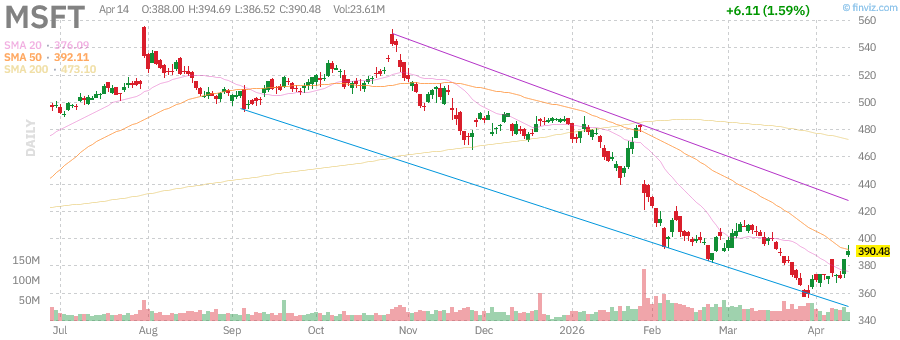

In [59]:
# --- chart printing ---
from pathlib import Path
from IPython.display import Image, display

output_dir = Path('asset')
output_dir.mkdir(parents=True, exist_ok=True)

failed_chart_tickers = []

for ticker in df.symbol.dropna().unique():
    try:
        stock_obj = finvizfinance(ticker)
        stock_obj.ticker_charts(out_dir=str(output_dir))
        plot_volume_profile(ticker)
        plot_volume_profile_10y_5y(ticker)

        candidate_paths = [
            output_dir / f'{ticker}.jpg',
            output_dir / f'{ticker}.jpeg',
            Path(f'{ticker}.jpg'),
            Path(f'{ticker}.jpeg'),
        ]
        image_path = next((p for p in candidate_paths if p.exists()), None)

        if image_path is not None:
            display(Image(filename=str(image_path)))
        else:
            failed_chart_tickers.append(ticker)
    except Exception:
        failed_chart_tickers.append(ticker)

if failed_chart_tickers:
    print('Chart image not available for:')
    print(failed_chart_tickers)